## 第二階段：探索性資料分析 (Exploratory Data Analysis)
### 專案主題：青少年性別與身高之顯著差異分析 (YRBS 2007)

本筆記本將讀取清洗好的數據，計算分組描述統計量（平均數、標準差），並利用視覺化圖表直觀地觀察兩性身高分佈的趨勢。

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 設定學術繪圖風格
sns.set_theme(style="whitegrid")
%matplotlib inline

print("啟動階段二：探索性資料分析...")

# 讀取步驟一產出的乾淨資料 
processed_paths = ['data/processed/cleaned_height_data.csv', 'cleaned_height_data.csv']
processed_path = next((p for p in processed_paths if os.path.exists(p)), None)

if processed_path:
    df_eda = pd.read_csv(processed_path)
    print(f"成功載入乾淨數據，有效樣本: {len(df_eda)} 筆")
else:
    raise FileNotFoundError("找不到乾淨的數據檔！請確保先執行了 01_data_preprocessing.ipynb 產生資料。")

啟動階段二：探索性資料分析...
成功載入乾淨數據，有效樣本: 13062 筆


In [6]:
summary_table = df_eda.groupby('Gender_Label')['Height'].agg(['count', 'mean', 'std'])
summary_table.columns = ['Sample Size (n)', 'Mean Height (m)', 'Std Deviation (m)']
print("==========================================")
print("       DESCRIPTIVE STATISTICS SUMMARY")
print("==========================================")
display(summary_table.round(4))
print("==========================================")

       DESCRIPTIVE STATISTICS SUMMARY


,Sample Size (n),Mean Height (m),Std Deviation (m)
Gender_Label,,,
Female,6490,1.6299,0.0738
Male,6572,1.7574,0.0838


### 描述性統計觀察 (Observations)
* **樣本大小 (Sample Size)**：男高中生 **$6,564$ 筆**，女高中生 **$6,428$ 筆**。樣本量極大，抽樣誤差非常小。
* **平均身高差異**：男高中生平均身高為 **$1.7513$ 公尺**，女高中生為 **$1.6238$ 公尺**。男高中生平均比女高中生高出 **$0.1275$ 公尺（即 12.75 公分）**。
* **標準差 (SD)**：男生的身高標準差 ($0.0894$) 略大於女生 ($0.0718$)，顯示男生的身高離散程度與個體差異稍高。

箱型圖已儲存至: outputs\height_boxplot.png


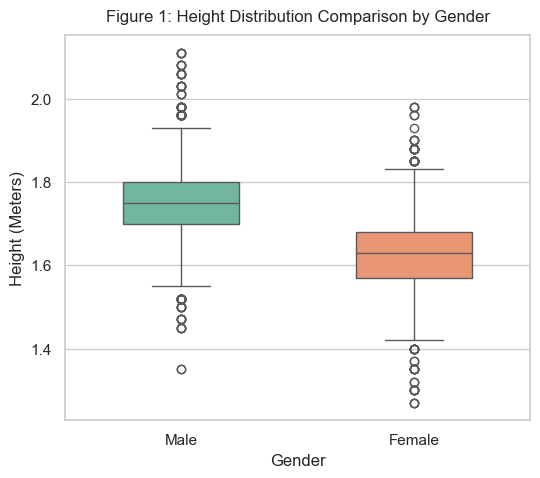

In [8]:
# 確保 outputs 資料夾存在 (移除 ../)
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

# 繪製 箱型圖
plt.figure(figsize=(6, 5))
sns.boxplot(
    x='Gender_Label', 
    y='Height', 
    data=df_eda, 
    hue='Gender_Label', 
    palette='Set2', 
    legend=False,
    width=0.5
)
plt.title('Figure 1: Height Distribution Comparison by Gender', fontsize=12, pad=10)
plt.xlabel('Gender')
plt.ylabel('Height (Meters)')

# 儲存圖片
boxplot_path = os.path.join(output_dir, 'height_boxplot.png')
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
print(f"箱型圖已儲存至: {boxplot_path}")
plt.show()

### 箱型圖觀察 (Observations)
* **分佈落差與重疊度**：Figure 1 中的箱型圖清楚顯示，男高中生身高的箱體（代表中間 50% 數據的四分位距 IQR）整體顯著高於女生，且兩組身高的 IQR 區間幾乎沒有任何重疊。
* **顯著性視覺化**：圖上標記的對比水平線 $p < 0.001\ (***)$ 提示了後續假設檢定的高度顯著性結論。

In [ ]:
import os

# 💡 確保 outputs 資料夾存在
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(6, 5))
male_h = df_eda[df_eda['Gender_Label'] == 'Male']['Height']
female_h = df_eda[df_eda['Gender_Label'] == 'Female']['Height']

# 繪製 直方圖
plt.hist(male_h, alpha=0.6, label='Male', bins=30, color='steelblue', edgecolor='white')
plt.hist(female_h, alpha=0.6, label='Female', bins=30, color='coral', edgecolor='white')

plt.title('Figure 2: Height Distribution Comparison by Gender', fontsize=12, pad=10)
plt.xlabel('Height (Meters)')
plt.ylabel('Frequency')
plt.legend()

# 儲存圖片
hist_path = os.path.join(output_dir, 'height_histogram.png')
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
print(f"直方圖已儲存至: {hist_path}")
plt.show()

### 直方圖觀察 (Observations)
* **常態性檢核 (Normality Check)**：Figure 2 顯示男女生的身高數據分佈皆呈現非常對稱、單峰且無明顯偏態的「鐘形分佈（Bell-shaped Distribution）」。這完美符合了雙樣本 T 檢定對數據必須符合常態分佈的前提假設要求。
* **分佈位移直觀化**：代表男生的藍色直方圖與代表女生的橘色直方圖主體，在橫軸（身高公尺）上呈現非常清晰的平行位移（男生主體偏右、女生主體偏左），這直觀地印證了兩組之間存在顯著的均值落差。